In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install xgboost
import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

In [26]:
import os   ## checking whether the file exists or not 
print(os.path.exists(r"D:\spot_price\spot_price_DE2026.csv"))


True


In [27]:
df = pd.read_csv(r"D:\spot_price\spot_price_DE2026.csv")


In [28]:

df.columns

Index(['Date (GMT+1)', 'Non-Renewable', 'Renewable', 'Load', 'Load forecast',
       'Day Ahead Auction (DE-LU)'],
      dtype='object')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6529 entries, 0 to 6528
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Date (GMT+1)               6528 non-null   object
 1   Non-Renewable              6422 non-null   object
 2   Renewable                  6422 non-null   object
 3   Load                       6422 non-null   object
 4   Load forecast              108 non-null    object
 5   Day Ahead Auction (DE-LU)  6529 non-null   object
dtypes: object(6)
memory usage: 306.2+ KB


In [30]:
df.head(10)

,Date (GMT+1),Non-Renewable,Renewable,Load,Load forecast,Day Ahead Auction (DE-LU)
0,NaN,Power (MW),Power (MW),Power (MW),Power (MW),"Price (EUR/MWh, EUR/tCO2)"
1,2026-01-01T00:00+01:00,17485.16218,39923.29863,45373.89574,NaN,63.64
2,2026-01-01T00:15+01:00,16743.10938,40670.70072,45010.67654,NaN,61.48
3,2026-01-01T00:30+01:00,16241.24649,41786.34534,45095.33353,NaN,58
4,2026-01-01T00:45+01:00,15895.99453,42425.50764,44988.21544,NaN,49.99
5,2026-01-01T01:00+01:00,15135.47839,42990.63503,44981.17025,NaN,60.01
6,2026-01-01T01:15+01:00,14962.49777,43530.80908,44963.75686,NaN,48.9
7,2026-01-01T01:30+01:00,14759.07984,44094.7794,44872.11055,NaN,36.74
8,2026-01-01T01:45+01:00,14545.42389,43983.72207,44674.7077,NaN,23.93
9,2026-01-01T02:00+01:00,14079.57896,44874.78391,44487.48783,NaN,36.01


In [31]:
df.tail(10)

,Date (GMT+1),Non-Renewable,Renewable,Load,Load forecast,Day Ahead Auction (DE-LU)
6519,2026-03-09T21:30+01:00,NaN,NaN,NaN,56633.85408,146.7
6520,2026-03-09T21:45+01:00,NaN,NaN,NaN,55767.65393,134.69
6521,2026-03-09T22:00+01:00,NaN,NaN,NaN,55011.18119,155.09
6522,2026-03-09T22:15+01:00,NaN,NaN,NaN,54124.49953,144.69
6523,2026-03-09T22:30+01:00,NaN,NaN,NaN,53082.80301,143.12
6524,2026-03-09T22:45+01:00,NaN,NaN,NaN,51964.22726,130.18
6525,2026-03-09T23:00+01:00,NaN,NaN,NaN,50961.75815,139.13
6526,2026-03-09T23:15+01:00,NaN,NaN,NaN,50196.36689,134.38
6527,2026-03-09T23:30+01:00,NaN,NaN,NaN,49432.66647,128
6528,2026-03-09T23:45+01:00,NaN,NaN,NaN,48796.8835,129.27


In [69]:
df.isna().sum()    # missing values

0       1
1     107
2     107
3     107
4    6421
5       0
dtype: int64

In [90]:
df = pd.read_csv(r"D:\spot_price\spot_price_DE2026.csv",skiprows=1 )
df.head()

,Unnamed: 0,Power (MW),Power (MW).1,Power (MW).2,Power (MW).3,"Price (EUR/MWh, EUR/tCO2)"
0,2026-01-01T00:00+01:00,17485.16218,39923.29863,45373.89574,NaN,63.64
1,2026-01-01T00:15+01:00,16743.10938,40670.70072,45010.67654,NaN,61.48
2,2026-01-01T00:30+01:00,16241.24649,41786.34534,45095.33353,NaN,58.00
3,2026-01-01T00:45+01:00,15895.99453,42425.50764,44988.21544,NaN,49.99
4,2026-01-01T01:00+01:00,15135.47839,42990.63503,44981.17025,NaN,60.01


In [91]:
df.columns = ['Datetime', 'Non-Ren(MW)', 'Ren(MW)', 'Load(MW)', 'Load_forecast', 'DA_price(EUR/MWh)']

df.head()


,Datetime,Non-Ren(MW),Ren(MW),Load(MW),Load_forecast,DA_price(EUR/MWh)
0,2026-01-01T00:00+01:00,17485.16218,39923.29863,45373.89574,NaN,63.64
1,2026-01-01T00:15+01:00,16743.10938,40670.70072,45010.67654,NaN,61.48
2,2026-01-01T00:30+01:00,16241.24649,41786.34534,45095.33353,NaN,58.00
3,2026-01-01T00:45+01:00,15895.99453,42425.50764,44988.21544,NaN,49.99
4,2026-01-01T01:00+01:00,15135.47839,42990.63503,44981.17025,NaN,60.01


In [94]:
## Convert Date Column to Time Series

df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')


In [95]:
df.head()

,Non-Ren(MW),Ren(MW),Load(MW),Load_forecast,DA_price(EUR/MWh)
Datetime,,,,,
2026-01-01 00:00:00+01:00,17485.16218,39923.29863,45373.89574,NaN,63.64
2026-01-01 00:15:00+01:00,16743.10938,40670.70072,45010.67654,NaN,61.48
2026-01-01 00:30:00+01:00,16241.24649,41786.34534,45095.33353,NaN,58.00
2026-01-01 00:45:00+01:00,15895.99453,42425.50764,44988.21544,NaN,49.99
2026-01-01 01:00:00+01:00,15135.47839,42990.63503,44981.17025,NaN,60.01


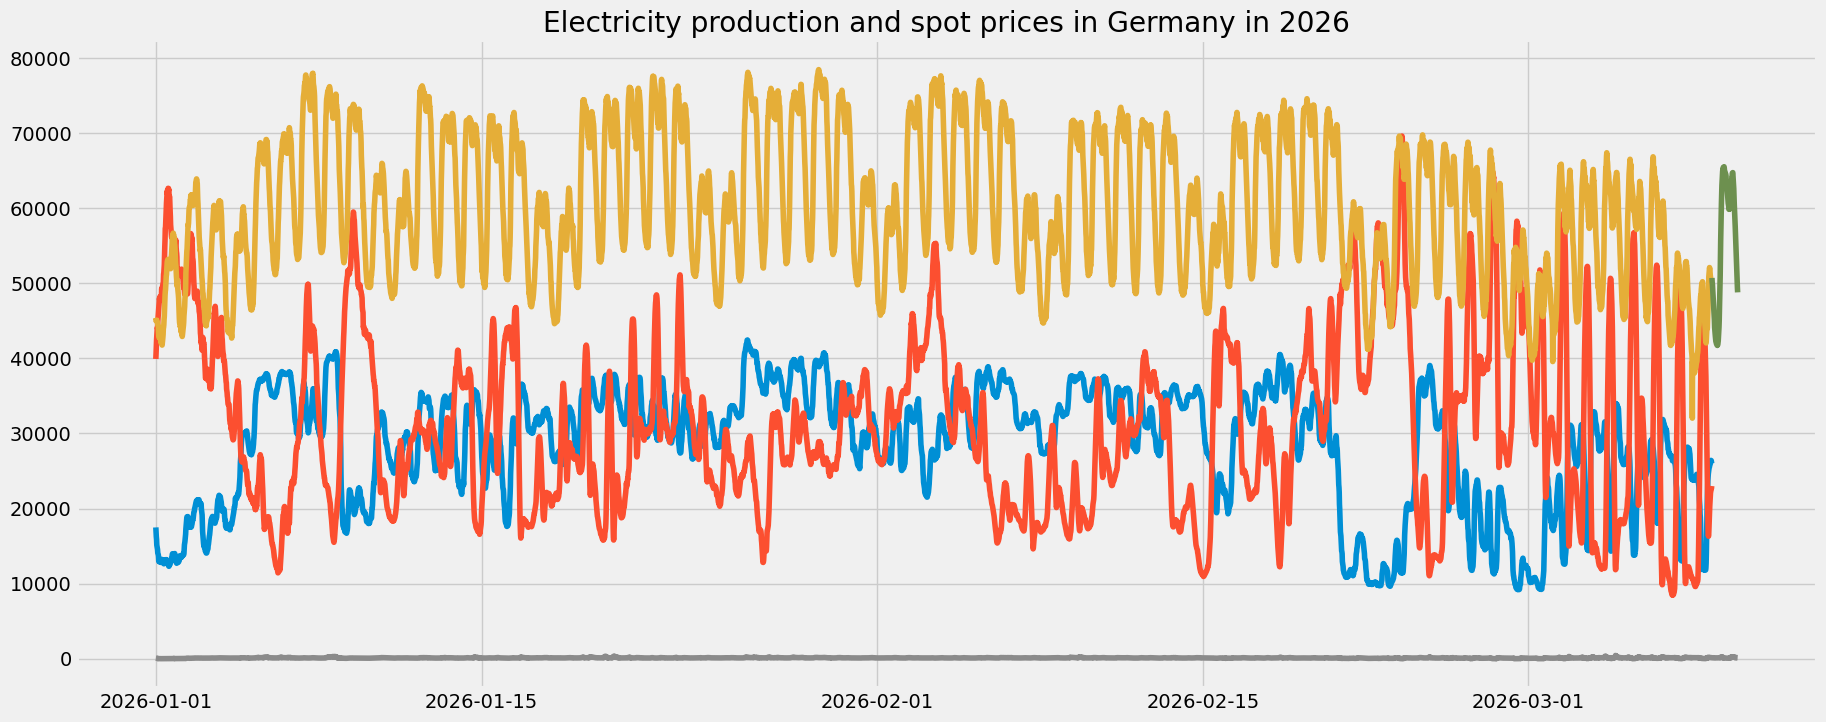

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))
plt.plot(df)
plt.title("Electricity production and spot prices in Germany in 2026")
plt.show()

In [100]:
df["price_lag1"] = df["DA_price(EUR/MWh)"].shift(1)   

#Electricity prices are highly autocorrelated.

#####  price at time t depends strongly on price at t-1

In [102]:
#Previous Day Price

df["price_lag24"] = df["DA_price(EUR/MWh)"].shift(24)

#### yesterday’s same hour behaviour

In [105]:
#Price Volatility

df["price_volatility"] = df["DA_price(EUR/MWh)"].rolling(24).std()

In [109]:
df["hour"] = df.index.hour
df.head(10)

,Non-Ren(MW),Ren(MW),Load(MW),Load_forecast,DA_price(EUR/MWh),price_lag1,price_lag24,price_volatility,hour
Datetime,,,,,,,,,
2026-01-01 00:00:00+01:00,17485.16218,39923.29863,45373.89574,NaN,63.64,NaN,NaN,NaN,0
2026-01-01 00:15:00+01:00,16743.10938,40670.70072,45010.67654,NaN,61.48,63.64,NaN,NaN,0
2026-01-01 00:30:00+01:00,16241.24649,41786.34534,45095.33353,NaN,58.00,61.48,NaN,NaN,0
2026-01-01 00:45:00+01:00,15895.99453,42425.50764,44988.21544,NaN,49.99,58.00,NaN,NaN,0
2026-01-01 01:00:00+01:00,15135.47839,42990.63503,44981.17025,NaN,60.01,49.99,NaN,NaN,1
2026-01-01 01:15:00+01:00,14962.49777,43530.80908,44963.75686,NaN,48.90,60.01,NaN,NaN,1
2026-01-01 01:30:00+01:00,14759.07984,44094.77940,44872.11055,NaN,36.74,48.90,NaN,NaN,1
2026-01-01 01:45:00+01:00,14545.42389,43983.72207,44674.70770,NaN,23.93,36.74,NaN,NaN,1
2026-01-01 02:00:00+01:00,14079.57896,44874.78391,44487.48783,NaN,36.01,23.93,NaN,NaN,2


In [112]:
df["day_of_week"] = df.index.dayofweek

In [115]:
df.head(10)

,Non-Ren(MW),Ren(MW),Load(MW),Load_forecast,DA_price(EUR/MWh),price_lag1,price_lag24,price_volatility,hour,day_of_week
Datetime,,,,,,,,,,
2026-01-01 00:00:00+01:00,17485.16218,39923.29863,45373.89574,NaN,63.64,NaN,NaN,NaN,0,3
2026-01-01 00:15:00+01:00,16743.10938,40670.70072,45010.67654,NaN,61.48,63.64,NaN,NaN,0,3
2026-01-01 00:30:00+01:00,16241.24649,41786.34534,45095.33353,NaN,58.00,61.48,NaN,NaN,0,3
2026-01-01 00:45:00+01:00,15895.99453,42425.50764,44988.21544,NaN,49.99,58.00,NaN,NaN,0,3
2026-01-01 01:00:00+01:00,15135.47839,42990.63503,44981.17025,NaN,60.01,49.99,NaN,NaN,1,3
2026-01-01 01:15:00+01:00,14962.49777,43530.80908,44963.75686,NaN,48.90,60.01,NaN,NaN,1,3
2026-01-01 01:30:00+01:00,14759.07984,44094.77940,44872.11055,NaN,36.74,48.90,NaN,NaN,1,3
2026-01-01 01:45:00+01:00,14545.42389,43983.72207,44674.70770,NaN,23.93,36.74,NaN,NaN,1,3
2026-01-01 02:00:00+01:00,14079.57896,44874.78391,44487.48783,NaN,36.01,23.93,NaN,NaN,2,3


In [116]:
df["renewable_share"] = df["Ren(MW)"] / df["Load(MW)"]
df.head(10)

,Non-Ren(MW),Ren(MW),Load(MW),Load_forecast,DA_price(EUR/MWh),price_lag1,price_lag24,price_volatility,hour,day_of_week,renewable_share
Datetime,,,,,,,,,,,
2026-01-01 00:00:00+01:00,17485.16218,39923.29863,45373.89574,NaN,63.64,NaN,NaN,NaN,0,3,0.879874
2026-01-01 00:15:00+01:00,16743.10938,40670.70072,45010.67654,NaN,61.48,63.64,NaN,NaN,0,3,0.903579
2026-01-01 00:30:00+01:00,16241.24649,41786.34534,45095.33353,NaN,58.00,61.48,NaN,NaN,0,3,0.926622
2026-01-01 00:45:00+01:00,15895.99453,42425.50764,44988.21544,NaN,49.99,58.00,NaN,NaN,0,3,0.943036
2026-01-01 01:00:00+01:00,15135.47839,42990.63503,44981.17025,NaN,60.01,49.99,NaN,NaN,1,3,0.955747
2026-01-01 01:15:00+01:00,14962.49777,43530.80908,44963.75686,NaN,48.90,60.01,NaN,NaN,1,3,0.968131
2026-01-01 01:30:00+01:00,14759.07984,44094.77940,44872.11055,NaN,36.74,48.90,NaN,NaN,1,3,0.982677
2026-01-01 01:45:00+01:00,14545.42389,43983.72207,44674.70770,NaN,23.93,36.74,NaN,NaN,1,3,0.984533
2026-01-01 02:00:00+01:00,14079.57896,44874.78391,44487.48783,NaN,36.01,23.93,NaN,NaN,2,3,1.008706


In [120]:
df["hour"] = df.index.hour

hourly_price = df.groupby("hour")["DA_price(EUR/MWh)"].mean()

df.head(50)

,Non-Ren(MW),Ren(MW),Load(MW),Load_forecast,DA_price(EUR/MWh),price_lag1,price_lag24,price_volatility,hour,day_of_week,renewable_share
Datetime,,,,,,,,,,,
2026-01-01 00:00:00+01:00,17485.16218,39923.29863,45373.89574,NaN,63.64,NaN,NaN,NaN,0,3,0.879874
2026-01-01 00:15:00+01:00,16743.10938,40670.70072,45010.67654,NaN,61.48,63.64,NaN,NaN,0,3,0.903579
2026-01-01 00:30:00+01:00,16241.24649,41786.34534,45095.33353,NaN,58.00,61.48,NaN,NaN,0,3,0.926622
2026-01-01 00:45:00+01:00,15895.99453,42425.50764,44988.21544,NaN,49.99,58.00,NaN,NaN,0,3,0.943036
2026-01-01 01:00:00+01:00,15135.47839,42990.63503,44981.17025,NaN,60.01,49.99,NaN,NaN,1,3,0.955747
2026-01-01 01:15:00+01:00,14962.49777,43530.80908,44963.75686,NaN,48.90,60.01,NaN,NaN,1,3,0.968131
2026-01-01 01:30:00+01:00,14759.07984,44094.77940,44872.11055,NaN,36.74,48.90,NaN,NaN,1,3,0.982677
2026-01-01 01:45:00+01:00,14545.42389,43983.72207,44674.70770,NaN,23.93,36.74,NaN,NaN,1,3,0.984533
2026-01-01 02:00:00+01:00,14079.57896,44874.78391,44487.48783,NaN,36.01,23.93,NaN,NaN,2,3,1.008706


<Axes: xlabel='hour'>

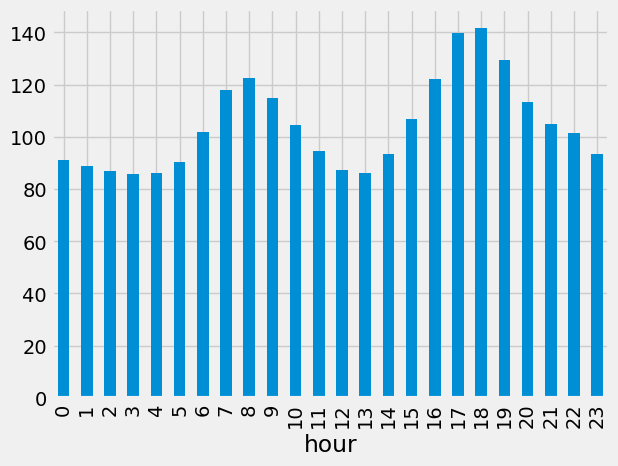

In [123]:
hourly_price.plot(kind="bar")

## night → low prices
## morning peak
## evening peak

In [125]:

df["residual_load"] = df["Load(MW)"] - df["Ren(MW)"]

df.head()

,Non-Ren(MW),Ren(MW),Load(MW),Load_forecast,DA_price(EUR/MWh),price_lag1,price_lag24,price_volatility,hour,day_of_week,renewable_share,residual_load
Datetime,,,,,,,,,,,,
2026-01-01 00:00:00+01:00,17485.16218,39923.29863,45373.89574,NaN,63.64,NaN,NaN,NaN,0,3,0.879874,5450.59711
2026-01-01 00:15:00+01:00,16743.10938,40670.70072,45010.67654,NaN,61.48,63.64,NaN,NaN,0,3,0.903579,4339.97582
2026-01-01 00:30:00+01:00,16241.24649,41786.34534,45095.33353,NaN,58.00,61.48,NaN,NaN,0,3,0.926622,3308.98819
2026-01-01 00:45:00+01:00,15895.99453,42425.50764,44988.21544,NaN,49.99,58.00,NaN,NaN,0,3,0.943036,2562.70780
2026-01-01 01:00:00+01:00,15135.47839,42990.63503,44981.17025,NaN,60.01,49.99,NaN,NaN,1,3,0.955747,1990.53522


# Electricity Price Forecasting

In [138]:
#Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [142]:
X = df[["price_lag1","price_lag24","residual_load","hour"]]
y = df["DA_price(EUR/MWh)"]


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,shuffle=False)
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]
X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]


model = LinearRegression()
model.fit(X_train,y_train)

predictions = model.predict(X_test)

In [144]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test,predictions)

11.67254403873008

In [ ]:
####  Algorithmic Trading Strategy

# If predicted price > current price → buy electricity
# If predicted price < current price → sell

In [151]:
df_test = X_test.copy()
df_test["actual_price"] = y_test
df_test["predicted_price"] = predictions

df_test["signal"] = df_test["predicted_price"] - df_test["actual_price"]

df_test["position"] = (df_test["signal"] > 0).astype(int)     

####  signal > 0 → model thinks price will rise → BUY ; signal ≤ 0 → stay out

In [152]:
df_test

,price_lag1,price_lag24,residual_load,hour,actual_price,predicted_price,signal,position
Datetime,,,,,,,,
2026-02-24 09:30:00+01:00,145.18,86.58,50397.69245,9,139.39,146.784785,7.394785,1
2026-02-24 09:45:00+01:00,139.39,89.38,49827.57354,9,131.29,141.415387,10.125387,1
2026-02-24 10:00:00+01:00,131.29,87.23,49117.16734,10,149.60,133.947915,-15.652085,0
2026-02-24 10:15:00+01:00,149.60,87.64,48864.07579,10,130.37,150.219693,19.849693,1
2026-02-24 10:30:00+01:00,130.37,88.01,48428.11796,10,121.62,132.931564,11.311564,1
...,...,...,...,...,...,...,...,...
2026-03-08 20:00:00+01:00,150.00,0.00,28065.12660,20,150.09,145.820056,-4.269944,0
2026-03-08 20:15:00+01:00,150.09,0.00,27521.45411,20,141.31,145.757692,4.447692,1
2026-03-08 20:30:00+01:00,141.31,7.46,26792.88610,20,135.78,137.592745,1.812745,1


In [156]:
## Computing Future Price Change       ; profit = next_price - current_price

df_test["price_change"] = df_test["actual_price"].shift(-1) - df_test["actual_price"]


In [157]:
## Strategy Profit

df_test["strategy_return"] = df_test["position"] * df_test["price_change"]

In [158]:
df_test

,price_lag1,price_lag24,residual_load,hour,actual_price,predicted_price,signal,position,price_change,strategy_return
Datetime,,,,,,,,,,
2026-02-24 09:30:00+01:00,145.18,86.58,50397.69245,9,139.39,146.784785,7.394785,1,-8.10,-8.10
2026-02-24 09:45:00+01:00,139.39,89.38,49827.57354,9,131.29,141.415387,10.125387,1,18.31,18.31
2026-02-24 10:00:00+01:00,131.29,87.23,49117.16734,10,149.60,133.947915,-15.652085,0,-19.23,-0.00
2026-02-24 10:15:00+01:00,149.60,87.64,48864.07579,10,130.37,150.219693,19.849693,1,-8.75,-8.75
2026-02-24 10:30:00+01:00,130.37,88.01,48428.11796,10,121.62,132.931564,11.311564,1,-8.14,-8.14
...,...,...,...,...,...,...,...,...,...,...
2026-03-08 20:00:00+01:00,150.00,0.00,28065.12660,20,150.09,145.820056,-4.269944,0,-8.78,-0.00
2026-03-08 20:15:00+01:00,150.09,0.00,27521.45411,20,141.31,145.757692,4.447692,1,-5.53,-5.53
2026-03-08 20:30:00+01:00,141.31,7.46,26792.88610,20,135.78,137.592745,1.812745,1,-7.79,-7.79


In [160]:
df_test["cumulative_profit"] = df_test["strategy_return"].cumsum()

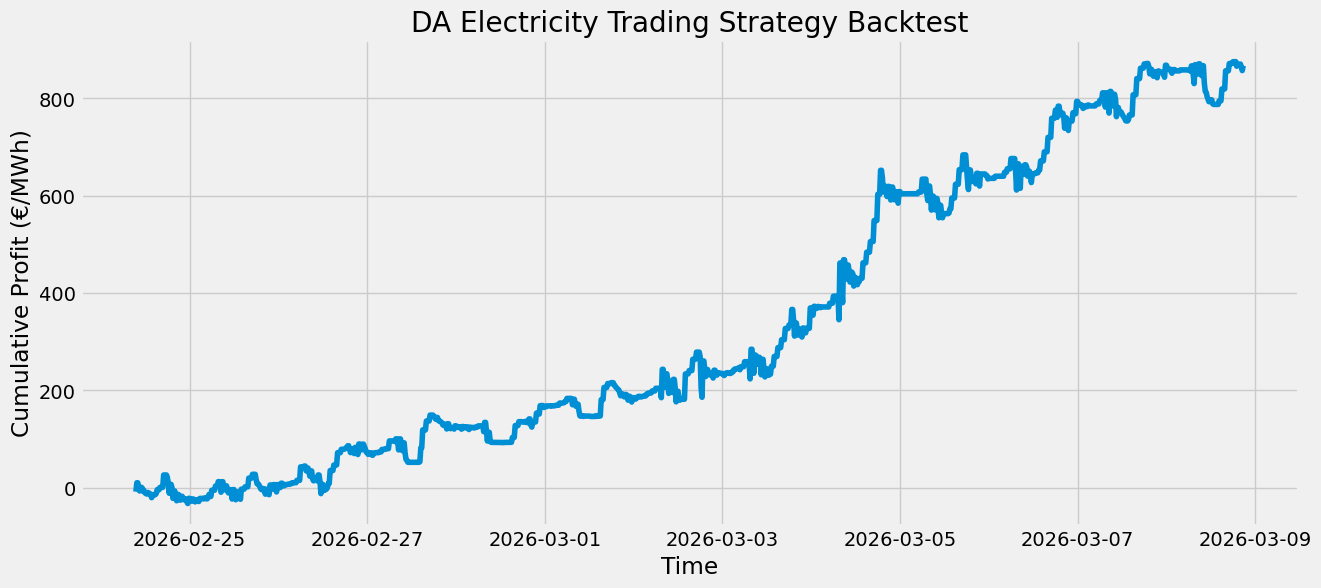

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df_test.index, df_test["cumulative_profit"])

plt.title("DA Electricity Trading Strategy Backtest")
plt.ylabel("Cumulative Profit (€/MWh)")
plt.xlabel("Time")

plt.show()

In [169]:
## Work in progress...